# Quiz: Stochastic Process Simulations

This notebook simulates and compares three discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 3) process

Each part includes a short analytical model and an empirical time-domain simulation.

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.style.use("seaborn-v0_8-whitegrid")


def design_fir_lpf(
    sample_rate_hz: float,  # Sampling frequency [Hz]
    cutoff_hz: float,  # Low-pass cutoff frequency [Hz]
    num_taps: int,  # FIR length [samples], must be odd
) -> NDArray[np.float64]:  # FIR impulse response h[n] with unit DC gain
    """Designs a linear-phase FIR LPF approximation to H(w) using windowed-sinc.

    Purpose:
        Build a practical discrete-time LPF for filtering white Gaussian noise.

    Parameters:
        sample_rate_hz: Sampling frequency in Hz.
        cutoff_hz: Desired cutoff frequency in Hz.
        num_taps: Number of FIR coefficients (odd for symmetry).

    Returns:
        Real FIR coefficients h[n], normalized to preserve DC gain.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")
    if not (0.0 < cutoff_hz < sample_rate_hz / 2.0):
        raise ValueError("cutoff_hz must be in (0, sample_rate_hz/2).")
    if num_taps < 3 or num_taps % 2 == 0:
        raise ValueError("num_taps must be an odd integer >= 3.")

    # Create a centered index and ideal LPF impulse response.
    n: NDArray[np.float64] = np.arange(num_taps, dtype=np.float64)
    center: float = (num_taps - 1) / 2.0
    normalized_cutoff: float = cutoff_hz / sample_rate_hz
    h_ideal: NDArray[np.float64] = (
        2.0
        * normalized_cutoff
        * np.sinc(2.0 * normalized_cutoff * (n - center))
    )

    # Apply a Hamming window to reduce sidelobes and normalize DC gain.
    h_windowed: NDArray[np.float64] = h_ideal * np.hamming(num_taps)
    h_windowed /= np.sum(h_windowed)
    return h_windowed.astype(np.float64)


def simulate_ar3(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # (a1, a2, a3) in AR recursion
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated AR(3) sequence
    """Simulates a stationary AR(3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = a1 x[n-1] + a2 x[n-2] + a3 x[n-3] + w[n],
        where w[n] is zero-mean white Gaussian noise.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` AR(3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    total_samples: int = num_samples + burn_in_samples

    # Draw innovations and run causal recursion from n=3 onward.
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        x[n_idx] = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
            + innovations[n_idx]
        )

    return x[burn_in_samples:]


def simulate_arma33(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # AR coefficients (a1, a2, a3)
    ma_coeffs: tuple[float, float, float],  # MA coefficients (b1, b2, b3)
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated ARMA(3,3) sequence
    """Simulates an ARMA(3,3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = sum(a_k x[n-k]) + w[n] + sum(b_k w[n-k])
        with k=1..3, combining long-memory AR feedback and short-memory MA shaping.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        ma_coeffs: MA coefficients (b1, b2, b3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` ARMA(3,3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    b1, b2, b3 = ma_coeffs

    # Keep three extra innovation samples for MA lags at startup.
    total_samples: int = num_samples + burn_in_samples + 3
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        # AR term models recursive memory from past outputs.
        ar_term: float = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
        )
        # MA term shapes current sample using current and delayed innovations.
        ma_term: float = (
            innovations[n_idx]
            + b1 * innovations[n_idx - 1]
            + b2 * innovations[n_idx - 2]
            + b3 * innovations[n_idx - 3]
        )
        x[n_idx] = ar_term + ma_term

    return x[burn_in_samples + 3 :]



def welch_psd_torch(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    sample_rate_hz: float,  # Sampling frequency [Hz]
    segment_length_samples: int = 512,  # Welch segment length [samples]
    overlap_samples: int | None = None,  # Segment overlap [samples]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (frequency_hz, PSD)
    """Estimates a one-sided PSD using a Welch method implemented in PyTorch.

    Purpose:
        Provide a deterministic, fully PyTorch-based PSD estimate suitable for
        stochastic-process analysis in this notebook.

    Parameters:
        signal_samples: 1-D discrete-time realization to analyze.
        sample_rate_hz: Sampling frequency in Hz.
        segment_length_samples: Window length used by Welch's method.
        overlap_samples: Overlap between adjacent windows. If ``None``, uses 50% overlap.

    Returns:
        A tuple ``(freq_hz, psd_power_per_hz)`` containing one-sided frequency bins
        and the averaged PSD estimate in power/Hz.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")

    x_tensor = torch.as_tensor(signal_samples, dtype=torch.float64)
    if x_tensor.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if segment_length_samples <= 0:
        raise ValueError("segment_length_samples must be positive.")
    if x_tensor.numel() < segment_length_samples:
        raise ValueError("segment_length_samples cannot exceed signal length.")

    if overlap_samples is None:
        overlap_samples = segment_length_samples // 2
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError(
            "overlap_samples must be in [0, segment_length_samples).",
        )

    # Split x[n] into overlapping segments using stride-based unfolding.
    step_samples: int = segment_length_samples - overlap_samples
    segments = x_tensor.unfold(
        dimension=0,
        size=segment_length_samples,
        step=step_samples,
    )

    # Remove local means and apply a Hann window before FFT.
    segments = segments - torch.mean(segments, dim=1, keepdim=True)
    window = torch.hann_window(
        segment_length_samples,
        periodic=False,
        dtype=torch.float64,
    )
    window_power: torch.Tensor = torch.sum(window**2)
    windowed_segments = segments * window

    # Compute one-sided periodograms and average them (Welch estimate).
    spectrum = torch.fft.rfft(windowed_segments, n=segment_length_samples, dim=1)
    psd_segments = (torch.abs(spectrum) ** 2) / (sample_rate_hz * window_power)

    if segment_length_samples % 2 == 0:
        psd_segments[:, 1:-1] *= 2.0
    else:
        psd_segments[:, 1:] *= 2.0

    psd_mean = torch.mean(psd_segments, dim=0)
    freq_hz = torch.fft.rfftfreq(segment_length_samples, d=1.0 / sample_rate_hz)

    return (
        freq_hz.detach().cpu().numpy().astype(np.float64),
        psd_mean.detach().cpu().numpy().astype(np.float64),
    )



def normalize_process_unit_variance(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    eps: float = 1e-12,  # Minimum allowed standard deviation
) -> NDArray[np.float64]:  # Zero-mean unit-variance sequence
    """Normalizes a sequence to zero mean and unit variance.

    Purpose:
        Enforce consistent amplitude scaling across time-domain realizations so
        PSD levels can be compared directly.

    Parameters:
        signal_samples: One-dimensional process realization.
        eps: Numerical floor for standard deviation validation.

    Returns:
        Normalized realization with empirical mean approximately zero and
        empirical variance equal to one.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(signal_samples, dtype=np.float64)
    if x.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")

    # Remove DC component before setting unit variance.
    x_centered: NDArray[np.float64] = x - float(np.mean(x))
    x_std: float = float(np.std(x_centered, ddof=0))
    if x_std <= eps:
        raise ValueError("signal standard deviation is too small to normalize.")

    return (x_centered / x_std).astype(np.float64)



def prepare_psd_db_for_omega_band(
    freq_hz: NDArray[np.float64],  # One-sided Welch frequency bins [Hz]
    psd_power_per_hz: NDArray[np.float64],  # One-sided PSD estimate [power/Hz]
    omega_max_rad_s: float,  # Maximum plotted angular frequency F [rad/s]
    min_psd_power: float = 1e-18,  # Lower bound before log conversion
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (omega_rad_s, PSD_dB)
    """Converts PSD to normalized dB scale and restricts it to omega in (0, F].

    Purpose:
        Prepare PSD curves for log-frequency plotting with a guaranteed 0 dB
        maximum in the displayed band.

    Parameters:
        freq_hz: One-sided discrete frequency bins from Welch estimation.
        psd_power_per_hz: PSD values associated with ``freq_hz``.
        omega_max_rad_s: Upper angular-frequency limit F for visualization.
        min_psd_power: Lower clipping floor to avoid log(0).

    Returns:
        Tuple ``(omega_rad_s, psd_db)`` where:
        - ``omega_rad_s`` only contains strictly positive values up to F.
        - ``psd_db`` is normalized so its maximum equals exactly 0 dB.

    Side effects:
        None.
    """
    if omega_max_rad_s <= 0.0:
        raise ValueError("omega_max_rad_s must be positive.")

    freq_array_hz: NDArray[np.float64] = np.asarray(freq_hz, dtype=np.float64)
    psd_array: NDArray[np.float64] = np.asarray(psd_power_per_hz, dtype=np.float64)
    if freq_array_hz.ndim != 1 or psd_array.ndim != 1:
        raise ValueError("freq_hz and psd_power_per_hz must be one-dimensional.")
    if freq_array_hz.shape != psd_array.shape:
        raise ValueError("freq_hz and psd_power_per_hz must have the same shape.")

    # Convert to angular frequency and keep only (0, F] for log-omega plotting.
    omega_rad_s: NDArray[np.float64] = 2.0 * np.pi * freq_array_hz
    band_mask: NDArray[np.bool_] = (
        (omega_rad_s > 0.0) & (omega_rad_s <= omega_max_rad_s)
    )
    if not np.any(band_mask):
        raise ValueError("No PSD bins remain inside the requested omega band.")

    omega_band_rad_s: NDArray[np.float64] = omega_rad_s[band_mask]
    psd_band: NDArray[np.float64] = np.maximum(psd_array[band_mask], min_psd_power)

    # Normalize dB level so the displayed maximum is exactly 0 dB.
    psd_band_db: NDArray[np.float64] = 10.0 * np.log10(psd_band)
    psd_band_db -= float(np.max(psd_band_db))

    return (
        omega_band_rad_s.astype(np.float64),
        psd_band_db.astype(np.float64),
    )



def autocorrelation_normalized_torch(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    max_lag_samples: int = 200,  # Maximum non-negative lag [samples]
    eps: float = 1e-18,  # Numerical guard for near-zero variance
) -> tuple[NDArray[np.int64], NDArray[np.float64]]:  # (lags, normalized_acf)
    """Computes normalized autocorrelation for non-negative lags using PyTorch.

    Purpose:
        Provide a consistent autocorrelation estimate for each normalized process
        so PSD and correlation behavior can be compared in one summary figure.

    Parameters:
        signal_samples: One-dimensional process realization.
        max_lag_samples: Largest lag index included in the result.
        eps: Small positive threshold to avoid division by very small values.

    Returns:
        Tuple ``(lags_samples, acf_normalized)`` where:
        - ``lags_samples`` spans ``0..max_lag_samples``.
        - ``acf_normalized`` equals ``R_x[k] / R_x[0]``.

    Side effects:
        None.
    """
    x_tensor = torch.as_tensor(signal_samples, dtype=torch.float64)
    if x_tensor.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if max_lag_samples < 0:
        raise ValueError("max_lag_samples must be non-negative.")

    num_samples: int = int(x_tensor.numel())
    if max_lag_samples >= num_samples:
        raise ValueError("max_lag_samples must be smaller than signal length.")

    # Remove the mean before estimating covariance-based correlations.
    x_centered = x_tensor - torch.mean(x_tensor)

    # Use the biased estimator (divide by N) for stable comparison across lags.
    acf_values = torch.empty(max_lag_samples + 1, dtype=torch.float64)
    for lag_idx in range(max_lag_samples + 1):
        acf_values[lag_idx] = (
            torch.dot(x_centered[: num_samples - lag_idx], x_centered[lag_idx:])
            / num_samples
        )

    acf_at_zero: torch.Tensor = acf_values[0]
    if torch.abs(acf_at_zero) <= eps:
        raise ValueError("autocorrelation at lag zero is too small to normalize.")

    acf_normalized = acf_values / acf_at_zero
    lags_samples = torch.arange(max_lag_samples + 1, dtype=torch.int64)

    return (
        lags_samples.detach().cpu().numpy().astype(np.int64),
        acf_normalized.detach().cpu().numpy().astype(np.float64),
    )


## 1) LPF $H(\omega)$ filtering AWGN (analytical)

Let $x[n] \sim \mathcal{N}(0,\sigma_x^2)$ be white Gaussian noise. For an LTI filter with
impulse response $h[n]$ and frequency response $H(e^{j\omega})$:

$$y[n] = (h * x)[n], \qquad S_y(e^{j\omega}) = |H(e^{j\omega})|^2 S_x(e^{j\omega}).$$

Since white noise has flat spectrum $S_x(e^{j\omega}) = \sigma_x^2$, the LPF attenuates
high-frequency power and reduces output variance according to:

$$\sigma_y^2 = \sigma_x^2 \sum_n h^2[n].$$

Below, $H(\omega)$ is implemented numerically as a windowed-sinc FIR LPF.

LPF output variance (theoretical): 0.1528
LPF output variance (empirical):   0.1516
LPF normalized mean:               +9.474e-18
LPF normalized variance:           1.0000


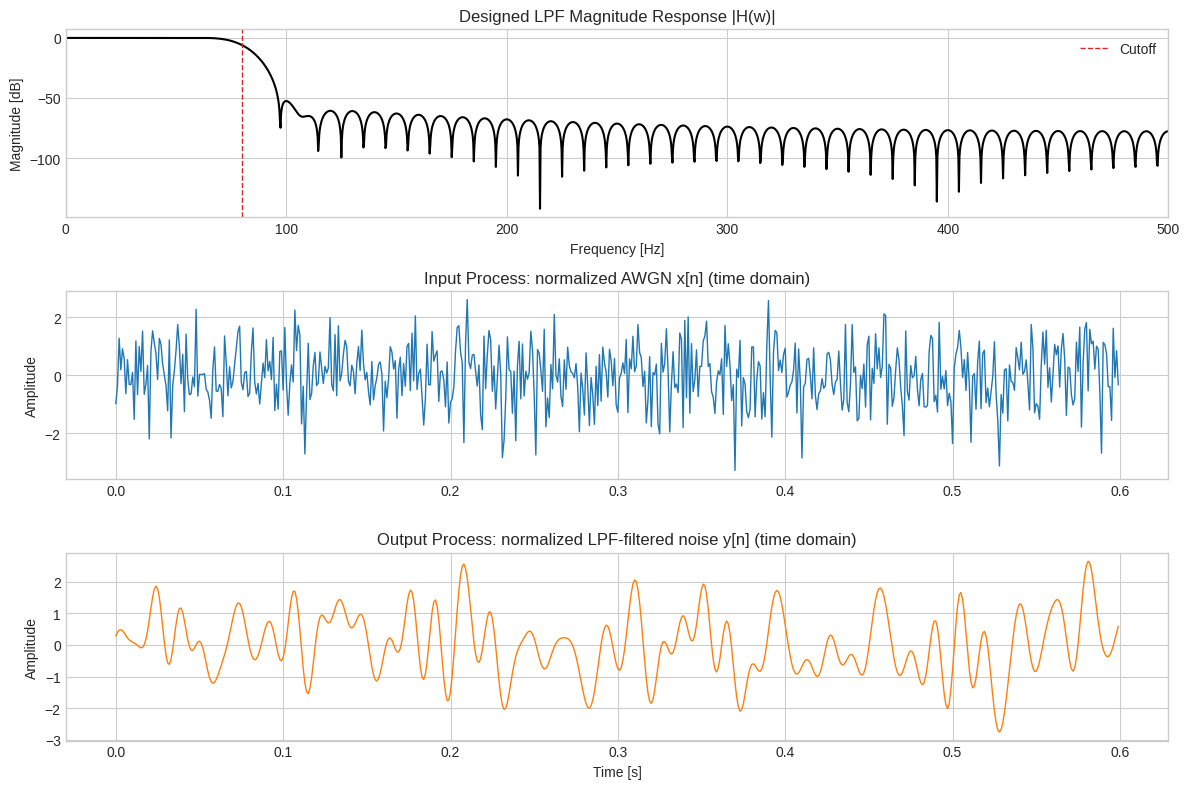

In [14]:
# Simulation parameters with explicit units.
sample_rate_hz: float = 1000.0  # Sampling frequency [Hz]
cutoff_hz: float = 80.0  # LPF cutoff frequency [Hz]
num_taps: int = 101  # FIR length [samples]
num_samples: int = 3000  # Signal length [samples]
noise_std: float = 1.0  # AWGN standard deviation

# Shared plotting parameters for the summary PSD/ACF figure.
omega_plot_limit_rad_s: float = 2.0 * np.pi * 200.0  # F = 2*pi*200 [rad/s]
psd_plot_floor_db: float = -30.0  # Lowest displayed PSD level [dB]
acf_max_lag_samples: int = 200  # Maximum displayed autocorrelation lag [samples]

# Generate AWGN input x[n].
rng_lpf = np.random.default_rng(seed=123)
x_awgn: NDArray[np.float64] = rng_lpf.normal(
    loc=0.0,
    scale=noise_std,
    size=num_samples,
).astype(np.float64)

# Build LPF H(w) and filter x[n] to produce y[n].
h_lpf: NDArray[np.float64] = design_fir_lpf(
    sample_rate_hz=sample_rate_hz,
    cutoff_hz=cutoff_hz,
    num_taps=num_taps,
)
y_lpf: NDArray[np.float64] = np.convolve(x_awgn, h_lpf, mode="same")

# Normalize all time-domain sequences used in this section.
x_awgn_norm: NDArray[np.float64] = normalize_process_unit_variance(x_awgn)
y_lpf_norm: NDArray[np.float64] = normalize_process_unit_variance(y_lpf)

# Compare theoretical and empirical output variance before normalization.
sigma_y2_theoretical: float = (noise_std**2) * float(np.sum(h_lpf**2))
sigma_y2_empirical: float = float(np.var(y_lpf, ddof=0))
print(f"LPF output variance (theoretical): {sigma_y2_theoretical:.4f}")
print(f"LPF output variance (empirical):   {sigma_y2_empirical:.4f}")
print(f"LPF normalized mean:               {np.mean(y_lpf_norm):+.3e}")
print(f"LPF normalized variance:           {np.var(y_lpf_norm, ddof=0):.4f}")

# Compute the discrete frequency response to visualize H(w).
fft_size: int = 4096
h_freq = np.fft.rfft(h_lpf, n=fft_size)
freq_hz: NDArray[np.float64] = np.fft.rfftfreq(
    fft_size,
    d=1.0 / sample_rate_hz,
)

# Plot H(w), normalized AWGN input, and normalized LPF output in time domain.
segment_samples: int = 600
time_s: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64) / sample_rate_hz

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(freq_hz, 20.0 * np.log10(np.maximum(np.abs(h_freq), 1e-8)), color="black")
axes[0].axvline(cutoff_hz, color="tab:red", linestyle="--", linewidth=1.0, label="Cutoff")
axes[0].set_title("Designed LPF Magnitude Response |H(w)|")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_xlim(0.0, sample_rate_hz / 2.0)
axes[0].legend()

axes[1].plot(
    time_s[:segment_samples],
    x_awgn_norm[:segment_samples],
    color="tab:blue",
    linewidth=1.0,
)
axes[1].set_title("Input Process: normalized AWGN x[n] (time domain)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(
    time_s[:segment_samples],
    y_lpf_norm[:segment_samples],
    color="tab:orange",
    linewidth=1.0,
)
axes[2].set_title("Output Process: normalized LPF-filtered noise y[n] (time domain)")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Estimate PSD of normalized LPF-filtered process for the summary figure.
welch_segment_lpf_samples: int = 512
welch_overlap_lpf_samples: int = 256
freq_lpf_psd_hz, psd_lpf_power_per_hz = welch_psd_torch(
    signal_samples=y_lpf_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_lpf_samples,
    overlap_samples=welch_overlap_lpf_samples,
)
omega_lpf_rad_s, psd_lpf_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_lpf_psd_hz,
    psd_power_per_hz=psd_lpf_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)


## 2) AR(3) process (analytical)

The AR(3) model is:

$$x[n] = a_1 x[n-1] + a_2 x[n-2] + a_3 x[n-3] + w[n], \quad w[n] \sim \mathcal{N}(0, \sigma_w^2).$$

With $A(z) = 1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}$, the transfer function from
innovation to output is $H(z) = 1/A(z)$. A stable AR part yields a stationary process.

Here we use poles $p = \{0.75, -0.45, 0.25\}$ in the recursion design, which gives:

$$a_1 = 0.55, \quad a_2 = 0.2625, \quad a_3 = -0.084375.$$

AR(3) normalized mean: +1.184e-17
AR(3) normalized var:  1.0000


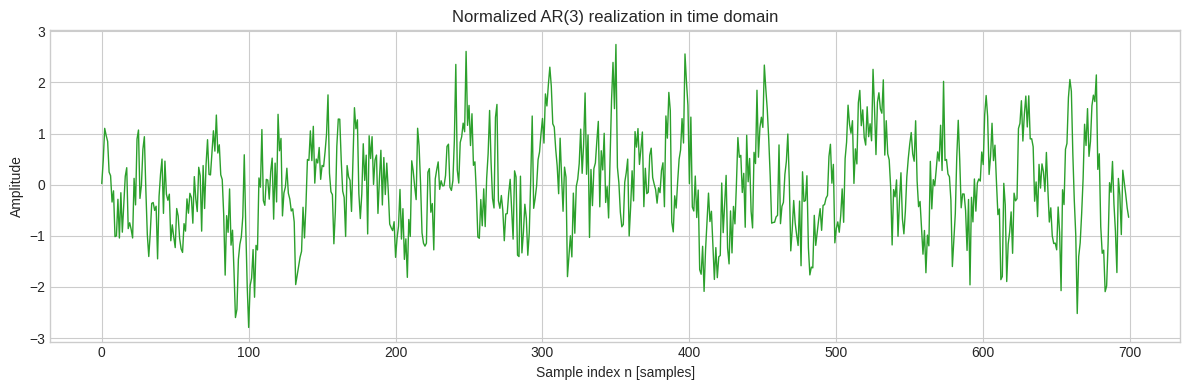

In [15]:
num_samples_ar3: int = 3000  # Output length [samples]
noise_std_ar3: float = 1.0  # Innovation standard deviation
ar3_coeffs: tuple[float, float, float] = (0.55, 0.2625, -0.084375)

x_ar3: NDArray[np.float64] = simulate_ar3(
    num_samples=num_samples_ar3,
    ar_coeffs=ar3_coeffs,
    noise_std=noise_std_ar3,
    burn_in_samples=600,
    random_seed=321,
)

# Normalize the AR(3) realization for consistent time-domain and PSD scaling.
x_ar3_norm: NDArray[np.float64] = normalize_process_unit_variance(x_ar3)

print(f"AR(3) normalized mean: {np.mean(x_ar3_norm):+.3e}")
print(f"AR(3) normalized var:  {np.var(x_ar3_norm, ddof=0):.4f}")

segment_samples_ar3: int = 700
n_ar3: NDArray[np.int64] = np.arange(num_samples_ar3, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_ar3[:segment_samples_ar3],
    x_ar3_norm[:segment_samples_ar3],
    color="tab:green",
    linewidth=1.0,
)
ax.set_title("Normalized AR(3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate PSD of normalized AR(3) realization for the summary figure.
welch_segment_ar3_samples: int = 512
welch_overlap_ar3_samples: int = 256
freq_ar3_psd_hz, psd_ar3_power_per_hz = welch_psd_torch(
    signal_samples=x_ar3_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_ar3_samples,
    overlap_samples=welch_overlap_ar3_samples,
)
omega_ar3_rad_s, psd_ar3_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_ar3_psd_hz,
    psd_power_per_hz=psd_ar3_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)


## 3) ARMA(3, 3) process (analytical)

The ARMA(3,3) model is:

$$x[n] = \sum_{k=1}^{3} a_k x[n-k] + w[n] + \sum_{k=1}^{3} b_k w[n-k],$$

with white innovation $w[n]$. The transfer function is:

$$H(z) = \frac{B(z)}{A(z)} = \frac{1 + b_1 z^{-1} + b_2 z^{-2} + b_3 z^{-3}}{1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}}.$$

Compared with pure AR, the MA part adds short-memory shaping of innovations,
while the AR part controls recursive structure.

We reuse the same AR coefficients and choose MA coefficients:

$$b_1 = 0.65, \quad b_2 = -0.35, \quad b_3 = 0.15.$$

ARMA(3,3) normalized mean: -4.737e-18
ARMA(3,3) normalized var:  1.0000


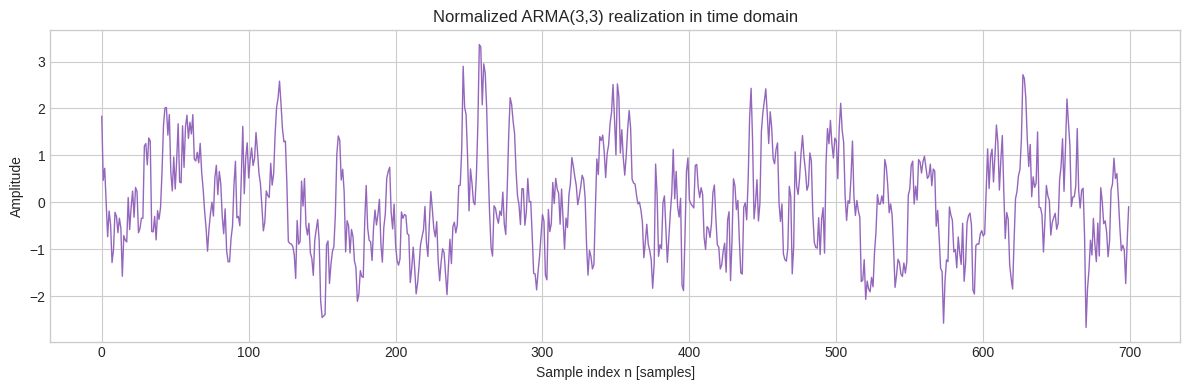

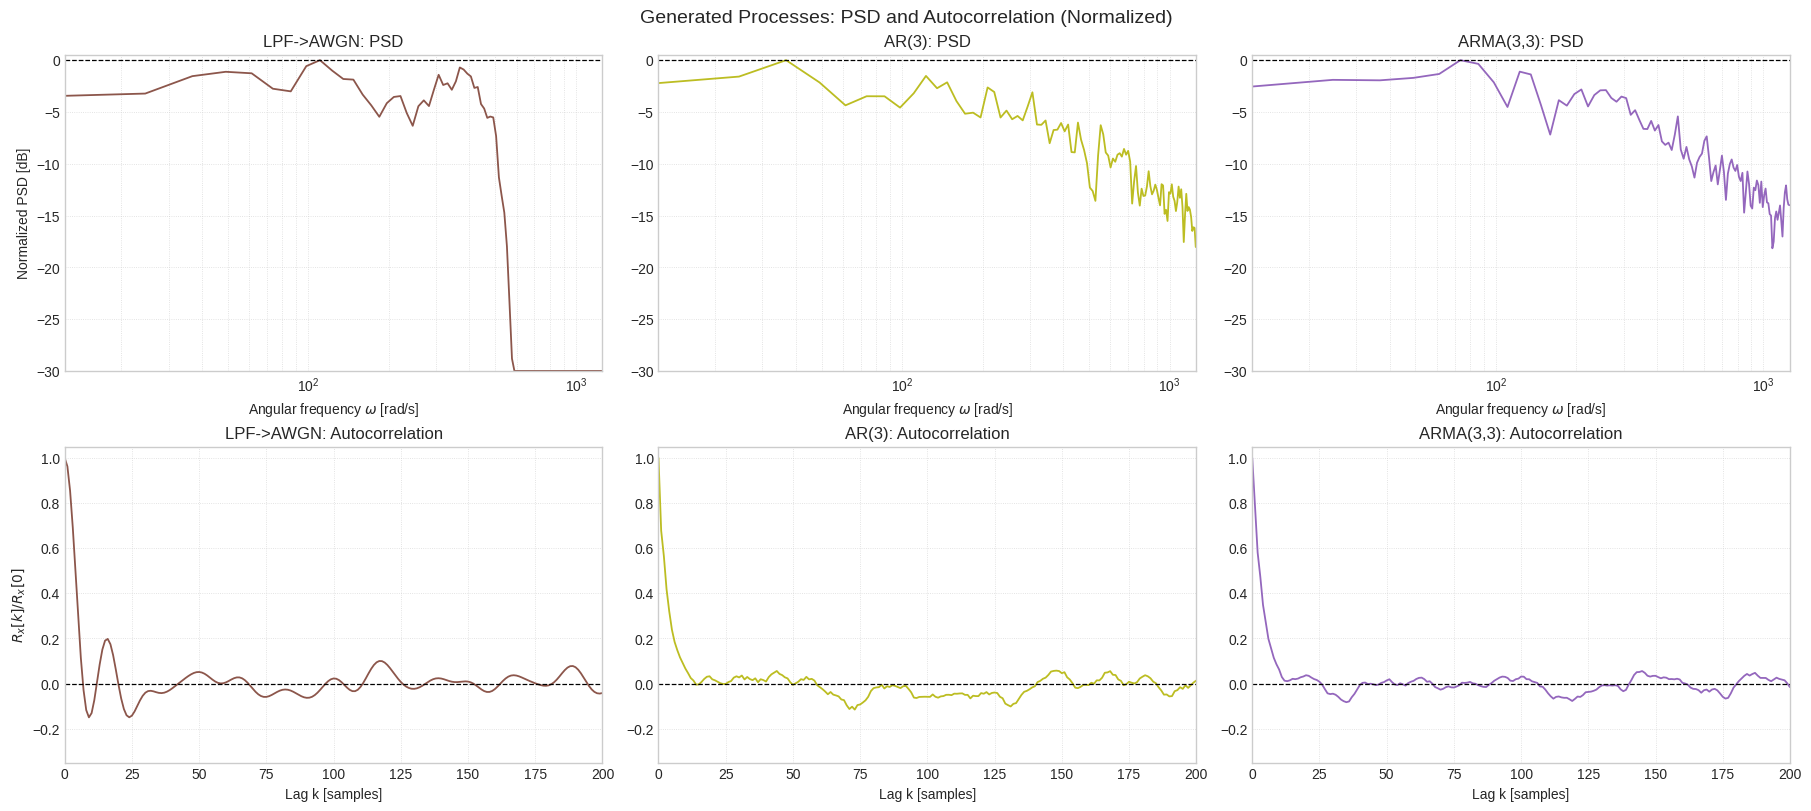

In [16]:
num_samples_arma33: int = 3000  # Output length [samples]
noise_std_arma33: float = 1.0  # Innovation standard deviation
ar_coeffs_arma33: tuple[float, float, float] = (0.55, 0.2625, -0.084375)
ma_coeffs_arma33: tuple[float, float, float] = (0.65, -0.35, 0.15)

x_arma33: NDArray[np.float64] = simulate_arma33(
    num_samples=num_samples_arma33,
    ar_coeffs=ar_coeffs_arma33,
    ma_coeffs=ma_coeffs_arma33,
    noise_std=noise_std_arma33,
    burn_in_samples=600,
    random_seed=999,
)

# Normalize the ARMA(3,3) realization for consistent time-domain and PSD scaling.
x_arma33_norm: NDArray[np.float64] = normalize_process_unit_variance(x_arma33)

print(f"ARMA(3,3) normalized mean: {np.mean(x_arma33_norm):+.3e}")
print(f"ARMA(3,3) normalized var:  {np.var(x_arma33_norm, ddof=0):.4f}")

segment_samples_arma: int = 700
n_arma: NDArray[np.int64] = np.arange(num_samples_arma33, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_arma[:segment_samples_arma],
    x_arma33_norm[:segment_samples_arma],
    color="tab:purple",
    linewidth=1.0,
)
ax.set_title("Normalized ARMA(3,3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate PSD of normalized ARMA(3,3) realization for the summary figure.
welch_segment_arma33_samples: int = 512
welch_overlap_arma33_samples: int = 256
freq_arma33_psd_hz, psd_arma33_power_per_hz = welch_psd_torch(
    signal_samples=x_arma33_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_arma33_samples,
    overlap_samples=welch_overlap_arma33_samples,
)
omega_arma33_rad_s, psd_arma33_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_arma33_psd_hz,
    psd_power_per_hz=psd_arma33_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)

# Create one summary figure with time-domain, PSD, and autocorrelation views.
summary_time_segment_samples: int = 700  # Visible time-domain length [samples]
summary_processes = [
    ("LPF->AWGN", omega_lpf_rad_s, psd_lpf_db, y_lpf_norm, "tab:brown"),
    ("AR(3)", omega_ar3_rad_s, psd_ar3_db, x_ar3_norm, "tab:olive"),
    ("ARMA(3,3)", omega_arma33_rad_s, psd_arma33_db, x_arma33_norm, "tab:purple"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 11), constrained_layout=True)
for col_idx, (label, omega_rad_s, psd_db, signal_norm, color) in enumerate(summary_processes):
    # Top row: normalized time-domain realizations for direct visual comparison.
    visible_samples: int = min(summary_time_segment_samples, signal_norm.size)
    n_visible: NDArray[np.int64] = np.arange(visible_samples, dtype=np.int64)
    ax_time = axes[0, col_idx]
    ax_time.plot(n_visible, signal_norm[:visible_samples], color=color, linewidth=1.1)
    ax_time.set_title(f"{label}: Time domain")
    ax_time.set_xlim(0, visible_samples - 1)
    ax_time.set_xlabel("Sample index n [samples]")
    ax_time.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_time.set_ylabel("Amplitude")

    # Middle row: PSD in dB, clipped so only values down to -30 dB are shown.
    psd_clipped_db: NDArray[np.float64] = np.maximum(psd_db, psd_plot_floor_db)
    ax_psd = axes[1, col_idx]
    ax_psd.plot(omega_rad_s, psd_clipped_db, color=color, linewidth=1.3)
    ax_psd.set_xscale("log")
    ax_psd.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    ax_psd.set_xlim(float(np.min(omega_rad_s)), omega_plot_limit_rad_s)
    ax_psd.set_ylim(psd_plot_floor_db, 0.5)
    ax_psd.set_title(f"{label}: PSD")
    ax_psd.set_xlabel(r"Angular frequency $\omega$ [rad/s]")
    ax_psd.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_psd.set_ylabel("Normalized PSD [dB]")

    # Bottom row: corresponding normalized autocorrelation.
    lags_samples, acf_normalized = autocorrelation_normalized_torch(
        signal_samples=signal_norm,
        max_lag_samples=acf_max_lag_samples,
    )
    ax_acf = axes[2, col_idx]
    ax_acf.plot(lags_samples, acf_normalized, color=color, linewidth=1.3)
    ax_acf.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    ax_acf.set_xlim(0, acf_max_lag_samples)
    ax_acf.set_ylim(-0.35, 1.05)
    ax_acf.set_title(f"{label}: Autocorrelation")
    ax_acf.set_xlabel("Lag k [samples]")
    ax_acf.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    if col_idx == 0:
        ax_acf.set_ylabel(r"$R_x[k] / R_x[0]$")

fig.suptitle(
    "Generated Processes: Time Domain, PSD, and Autocorrelation (Normalized)",
    fontsize=14,
)
plt.show()


## 4) Validity of $r_x(\lambda)=\sum_{k=-K}^{K} w_k e^{-\alpha_k\lambda^2}$

We analyze whether
$$
r_x(\lambda)=\sum_{k=-K}^{K} w_k\,e^{-\alpha_k\lambda^2},\qquad w_k\ge 0
$$
can be a valid autocorrelation function (ACF).

**Analytical verification (continuous-lag view):**

1. A function is a valid ACF of a wide-sense stationary process iff it is positive semidefinite (Bochner/Wiener-Khinchin characterization).
2. For each term with $\alpha_k>0$,
   $$
   \mathcal{F}\{e^{-\alpha_k\lambda^2}\}(\omega)
   =\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0.
   $$
3. Therefore,
   $$
   S_x(\omega)=\sum_{k=-K}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\,e^{-\omega^2/(4\alpha_k)}\ge 0
   $$
   whenever $w_k\ge 0$ and $\alpha_k>0$.
4. Also, $r_x(\lambda)$ is even and $r_x(0)=\sum_k w_k\ge 0$.

**Conclusion:** with finite $K$, nonnegative weights $w_k$, and positive rates $\alpha_k$, the expression is a valid ACF.

The next code cell verifies this numerically (Toeplitz PSD checks + nonnegative spectrum) and empirically (sampled Gaussian process ACF vs theory).


In [ ]:
# Parameters for a concrete instance of r_x(lambda) = sum_k w_k exp(-alpha_k lambda^2).
K_mix: int = 2
k_indices: NDArray[np.int64] = np.arange(-K_mix, K_mix + 1, dtype=np.int64)
weights_mix: NDArray[np.float64] = np.array([0.25, 0.55, 0.8, 0.55, 0.25], dtype=np.float64)
alphas_mix: NDArray[np.float64] = np.array([0.18, 0.35, 0.8, 0.35, 0.18], dtype=np.float64)


def gaussian_mixture_acf(
    lags: NDArray[np.float64],  # Lag values lambda [samples or continuous units]
    weights: NDArray[np.float64],  # Mixture coefficients w_k (must be nonnegative)
    alphas: NDArray[np.float64],  # Exponential rates alpha_k (must be positive)
) -> NDArray[np.float64]:  # Candidate autocorrelation values r_x(lambda)
    """Evaluates the Gaussian-mixture candidate autocorrelation function.

    Purpose:
        Compute r_x(lambda) = sum_k w_k exp(-alpha_k * lambda^2) and enforce
        parameter conditions required by the analytical validity argument.

    Parameters:
        lags: Points where the candidate ACF is evaluated.
        weights: Nonnegative coefficients multiplying each Gaussian kernel.
        alphas: Positive rates controlling kernel widths.

    Returns:
        A one-dimensional array with r_x evaluated at each lag.

    Side effects:
        None.
    """
    lag_array: NDArray[np.float64] = np.asarray(lags, dtype=np.float64)
    weight_array: NDArray[np.float64] = np.asarray(weights, dtype=np.float64)
    alpha_array: NDArray[np.float64] = np.asarray(alphas, dtype=np.float64)

    if weight_array.ndim != 1 or alpha_array.ndim != 1:
        raise ValueError("weights and alphas must be one-dimensional.")
    if weight_array.shape != alpha_array.shape:
        raise ValueError("weights and alphas must have the same shape.")
    if np.any(weight_array < 0.0):
        raise ValueError("All weights must satisfy w_k >= 0.")
    if np.any(alpha_array <= 0.0):
        raise ValueError("All alpha_k values must be strictly positive.")

    # Evaluate all kernels in a vectorized way and sum over k.
    lag_sq = lag_array[None, :] ** 2
    kernels = np.exp(-alpha_array[:, None] * lag_sq)
    return np.sum(weight_array[:, None] * kernels, axis=0).astype(np.float64)


def toeplitz_covariance_from_acf(
    num_samples: int,  # Matrix size N [samples]
    weights: NDArray[np.float64],  # Mixture coefficients w_k
    alphas: NDArray[np.float64],  # Exponential rates alpha_k
) -> NDArray[np.float64]:  # Toeplitz covariance matrix C in R^{N x N}
    """Builds a Toeplitz covariance matrix from the candidate ACF.

    Purpose:
        Numerically test positive semidefiniteness by creating C[i,j]=r_x(i-j)
        over integer lags and inspecting its eigenvalues.

    Parameters:
        num_samples: Dimension N of the covariance matrix.
        weights: Nonnegative mixture weights.
        alphas: Positive Gaussian rates.

    Returns:
        A symmetric Toeplitz covariance matrix implied by the candidate ACF.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")

    # Compute r_x[l] for l = 0, ..., N-1 and index with |i-j| to form Toeplitz C.
    lags_nonnegative: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64)
    acf_nonnegative: NDArray[np.float64] = gaussian_mixture_acf(
        lags=lags_nonnegative,
        weights=weights,
        alphas=alphas,
    )
    lag_indices: NDArray[np.int64] = np.abs(
        np.subtract.outer(np.arange(num_samples), np.arange(num_samples)),
    )
    return acf_nonnegative[lag_indices].astype(np.float64)


def ensemble_biased_acf(
    realizations: NDArray[np.float64],  # Shape (M, N) with M process realizations
    max_lag_samples: int,  # Largest lag index to estimate [samples]
) -> NDArray[np.float64]:  # Ensemble-averaged biased ACF estimate
    """Estimates non-negative-lag ACF using an ensemble-averaged biased estimator.

    Purpose:
        Compare empirical correlation behavior of simulated realizations against
        the theoretical normalized ACF implied by the candidate expression.

    Parameters:
        realizations: Matrix whose rows are process realizations.
        max_lag_samples: Maximum non-negative lag included in the estimate.

    Returns:
        One-dimensional array with ACF estimates for lags 0..max_lag_samples.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(realizations, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError("realizations must be two-dimensional with shape (M, N).")
    num_realizations, num_samples = x.shape
    if num_realizations <= 0 or num_samples <= 1:
        raise ValueError("realizations must contain at least one nontrivial row.")
    if max_lag_samples < 0 or max_lag_samples >= num_samples:
        raise ValueError("max_lag_samples must satisfy 0 <= lag < N.")

    # Remove each realization mean before covariance estimation.
    x_centered: NDArray[np.float64] = x - np.mean(x, axis=1, keepdims=True)
    acf_estimate = np.empty(max_lag_samples + 1, dtype=np.float64)

    # Use the biased estimator (divide by N) for stable lag-to-lag comparison.
    for lag_idx in range(max_lag_samples + 1):
        acf_estimate[lag_idx] = float(
            np.mean(x_centered[:, : num_samples - lag_idx] * x_centered[:, lag_idx:]),
        )
    return acf_estimate


# Numerical check 1: Toeplitz covariance matrices should be positive semidefinite.
matrix_sizes = [16, 32, 64, 128, 256]
min_eigenvalues: list[float] = []
for matrix_size in matrix_sizes:
    covariance_matrix = toeplitz_covariance_from_acf(
        num_samples=matrix_size,
        weights=weights_mix,
        alphas=alphas_mix,
    )
    min_eigenvalue = float(np.min(np.linalg.eigvalsh(covariance_matrix)))
    min_eigenvalues.append(min_eigenvalue)
    print(f"N={matrix_size:3d} | min eigenvalue = {min_eigenvalue:+.3e}")


# Numerical check 2: continuous-lag spectrum from analytic Fourier transform must be nonnegative.
omega_grid_rad = np.linspace(-30.0, 30.0, 2501)
spectral_density = np.sum(
    weights_mix[:, None]
    * np.sqrt(np.pi / alphas_mix)[:, None]
    * np.exp(-(omega_grid_rad[None, :] ** 2) / (4.0 * alphas_mix[:, None])),
    axis=0,
)
min_spectrum = float(np.min(spectral_density))
print(f"min S_x(omega) on grid = {min_spectrum:.6e}")


# Empirical check: sample a Gaussian vector process with this covariance and compare ACF.
num_samples_empirical: int = 512
num_realizations_empirical: int = 300
max_lag_empirical: int = 120

covariance_empirical = toeplitz_covariance_from_acf(
    num_samples=num_samples_empirical,
    weights=weights_mix,
    alphas=alphas_mix,
)

# Add a tiny diagonal jitter for numerical stability in multivariate sampling.
jitter_variance: float = 1e-10
covariance_empirical += jitter_variance * np.eye(num_samples_empirical)

rng_empirical = np.random.default_rng(seed=2026)
realizations_empirical: NDArray[np.float64] = rng_empirical.multivariate_normal(
    mean=np.zeros(num_samples_empirical, dtype=np.float64),
    cov=covariance_empirical,
    size=num_realizations_empirical,
).astype(np.float64)

acf_empirical = ensemble_biased_acf(
    realizations=realizations_empirical,
    max_lag_samples=max_lag_empirical,
)
lags_empirical = np.arange(max_lag_empirical + 1, dtype=np.float64)
acf_theoretical = gaussian_mixture_acf(
    lags=lags_empirical,
    weights=weights_mix,
    alphas=alphas_mix,
)

acf_empirical_normalized = acf_empirical / acf_empirical[0]
acf_theoretical_normalized = acf_theoretical / acf_theoretical[0]
acf_rmse = float(
    np.sqrt(np.mean((acf_empirical_normalized - acf_theoretical_normalized) ** 2)),
)
print(f"normalized ACF RMSE (empirical vs theory) = {acf_rmse:.3e}")


# Report a binary validity verdict using practical numerical tolerances.
eig_tolerance: float = 1e-9
spectrum_tolerance: float = 1e-12
is_psd_toeplitz = all(min_eig >= -eig_tolerance for min_eig in min_eigenvalues)
is_nonnegative_spectrum = bool(min_spectrum >= -spectrum_tolerance)

if is_psd_toeplitz and is_nonnegative_spectrum:
    print("Verdict: VALID ACF under w_k >= 0 and alpha_k > 0.")
else:
    print("Verdict: NOT validated as a valid ACF for these parameters.")


# Visual summary of numerical and empirical checks.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

axes[0].plot(matrix_sizes, min_eigenvalues, marker="o", color="tab:blue")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("Toeplitz PSD Check")
axes[0].set_xlabel("Matrix size N [samples]")
axes[0].set_ylabel("Minimum eigenvalue")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

axes[1].plot(omega_grid_rad, spectral_density, color="tab:green", linewidth=1.3)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
axes[1].set_title("Analytic Spectrum S_x(omega)")
axes[1].set_xlabel("omega [rad]")
axes[1].set_ylabel("Spectral density")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

axes[2].plot(
    lags_empirical,
    acf_theoretical_normalized,
    color="tab:red",
    linewidth=1.6,
    label="Theoretical",
)
axes[2].plot(
    lags_empirical,
    acf_empirical_normalized,
    color="tab:orange",
    linewidth=1.1,
    linestyle="--",
    label="Empirical",
)
axes[2].set_title("Normalized ACF: theory vs empirical")
axes[2].set_xlabel("Lag [samples]")
axes[2].set_ylabel("r_x[k] / r_x[0]")
axes[2].grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
axes[2].legend()

plt.show()
